# Imports

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### `cv2.imread(filename, flags)`
Loads an image from a file.
```python
image = cv2.imread(filename, flags)
```
- **filename**: Image file path.
- **flags** *(optional)*:
  - `cv2.IMREAD_UNCHANGED` or `-1`
  - `cv2.IMREAD_GRAYSCALE` or `0`
  - `cv2.IMREAD_COLOR` or `1` (default)
- Returns a NumPy array containing the image.

In [2]:
file = "./input/chelsea.jpg"
img = cv.imread(file)
if img is None:
    print("File Not Found")
    raise FileNotFoundError("Image not found.")
with np.printoptions( threshold=5, edgeitems=2):
    print(f"Image array: {img}")
print(f"Dimensions: {img.ndim}")
cv.imshow("window", img)
cv.waitKey(0)
cv.destroyAllWindows()

Image array: [[[ 26  44  97]
  [ 44  65 120]
  ...
  [  1   3   4]
  [  1   3   4]]

 [[  0   0  43]
  [ 54  70 116]
  ...
  [  1   3   4]
  [  1   3   4]]

 ...

 [[  9  20  40]
  [  8  17  37]
  ...
  [ 14  19  28]
  [ 14  19  28]]

 [[  2  13  27]
  [  2  11  25]
  ...
  [ 14  19  28]
  [ 14  19  28]]]
Dimensions: 3


The `img` 3-dimensional NumPy array of shape (rows, columns, channels), where each pixel contains three values representing the BGR color channels.

### `cv2.imwrite(filename, image)`
Saves an image to a file.
```python
success = cv2.imwrite(filename, image)
```
- **filename**: Output file path. The extension determines the image format.
- **image**: NumPy array containing the image.
- Returns `True` if the image is saved successfully, otherwise `False`.

In [3]:
if (cv.imwrite("output/chelsea.png", img)):
    print("Image saved successfully")
else:
    print("Failed to save image")

Image saved successfully


### `cv2.cvtColor(src, code)`
Converts an image from one color space to another.
```python
dst = cv2.cvtColor(src, code)
```
- **src**: Source image (NumPy array).
- **code**: Color conversion code.
- Returns a NumPy array containing the converted image.

In [4]:
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv.imwrite('output/chelsea_gray.png', gray_img)

True

## `image.shape`

Returns the dimensions of an image stored as a NumPy array.
`shape` is a **NumPy array attribute**, not an OpenCV function.
```python
image.shape
```
- Returns a tuple containing the dimensions of the image.
- For a **color image**: (height, width, channels)
- For a **grayscale image**: (height, width)

In [5]:
print("For color image")
print(f"Shape: {img.shape} (height, width, channels)")
print(f"Data Type: {img.dtype} (each pixel value occupies 8 bits)")
print(f"Pixel values range b/w: {img.min()} - {img.max()}")

print("\nFor gray img")
print(f"Shape: {gray_img.shape} (height, width)")
print(f"Data Type: {gray_img.dtype} (each pixel value occupies 8 bits)")
print(f"Pixel values range b/w: {gray_img.min()} - {img.max()}")

For color image
Shape: (300, 451, 3) (height, width, channels)
Data Type: uint8 (each pixel value occupies 8 bits)
Pixel values range b/w: 0 - 255

For gray img
Shape: (300, 451) (height, width)
Data Type: uint8 (each pixel value occupies 8 bits)
Pixel values range b/w: 0 - 255


### BGR vs RGB vs Grayscale

The figure below compares:
- Original BGR image shown directly in Matplotlib
- Correct RGB image
- Grayscale image

The BGR image appears with incorrect colors because Matplotlib assumes the channels are arranged as RGB.

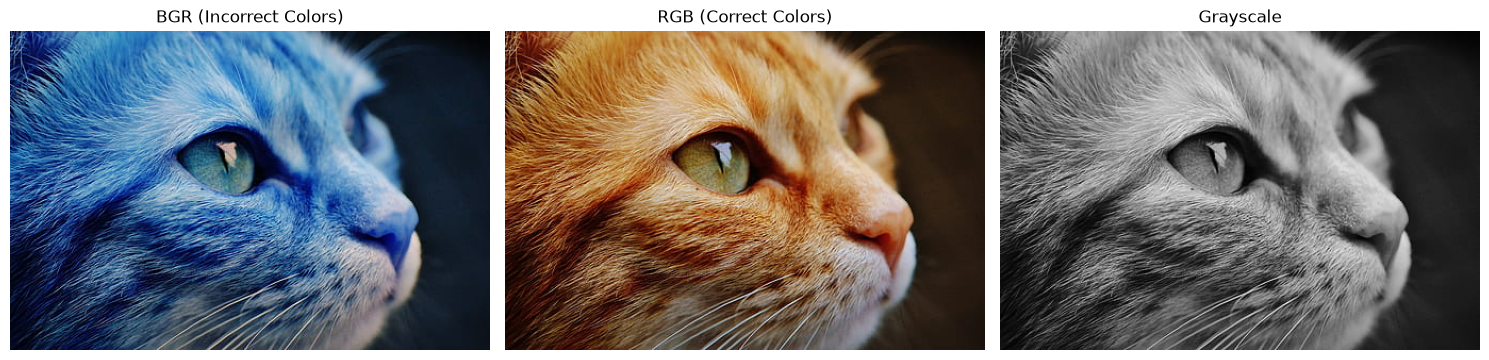

In [6]:
plt.figure(figsize=(15,5))

# Subplot Containing colour image (BGR)
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("BGR (Incorrect Colors)")
plt.axis("off")

# Subplot Containing colour image (RGB)
rgb_img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.subplot(1,3,2)
plt.imshow(rgb_img)
plt.title("RGB (Correct Colors)")
plt.axis("off")

# Subplot Containing gray image
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.subplot(1,3,3)
# If cmap is not set to grey The mad plot lip We'll expect Three values RGB
# @param `gray_img` is a 2D array containing values 0-255 (Black-White) 
plt.imshow(gray_img, cmap="gray")  
plt.title("Grayscale")
plt.axis("off")

plt.tight_layout()
plt.savefig("output/1_channels.png")
plt.show()